# NHL Draft Analysis — Methodology

In `formula.ipynb`, we calculated a **performance score** for every skater drafted between 2005 and 2017:

> Performance Score = games_played + (points × 2.29)

This formula captures both durability and offensive contribution in a single number, and it's the foundation of everything that follows.

The goal of this notebook is to turn those raw performance scores into something more meaningful: a **draft value** for every pick.

> Draft Value = performance_score − expected_performance

A positive draft value means the player *outperformed* what was historically expected at their draft position. A negative value means they fell short. A player who never appeared in an NHL game scores near zero — and since even modest expected performance at any pick position is positive, they'll land negative, which is exactly right.

The one question we still need to answer: **how do we calculate expected performance?** That's what this notebook works through.

## Setup

Load the draft scores produced by `formula.ipynb` and do a quick sanity check before we build anything.

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')

df = pd.read_csv('../data/outputs/draft_scores.csv')

print(f"Rows:    {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"Years:   {df['draft_year'].min()} – {df['draft_year'].max()}")
print(f"Nulls:\n{df.isnull().sum()}")
df.head(10)

Rows:    2484
Columns: ['draft_year', 'round', 'pick_number', 'drafted_by', 'player_name', 'position', 'games_played', 'points', 'performance_score']
Years:   2005 – 2017
Nulls:
draft_year           0
round                0
pick_number          0
drafted_by           0
player_name          0
position             0
games_played         0
points               0
performance_score    0
dtype: int64


,draft_year,round,pick_number,drafted_by,player_name,position,games_played,points,performance_score
0,2005,1,1,Pittsburgh Penguins,Sidney Crosby,C,1417.0,1756.0,1366.28
1,2005,1,2,Anaheim Ducks,Bobby Ryan,R,866.0,569.0,891.65
2,2005,1,3,Carolina Hurricanes,Jack Johnson,D,1228.0,342.0,583.05
3,2005,1,4,Minnesota Wild,Benoit Pouliot,L,625.0,263.0,699.05
4,2005,1,6,Columbus Blue Jackets,Gilbert Brule,C,299.0,95.0,516.55
5,2005,1,7,Chicago Blackhawks,Jack Skille,R,368.0,84.0,542.09
6,2005,1,8,San Jose Sharks,Devin Setoguchi,R,516.0,261.0,768.36
7,2005,1,9,Ottawa Senators,Brian Lee,D,209.0,36.0,291.44
8,2005,1,10,Vancouver Canucks,Luc Bourdon,D,36.0,2.0,40.58
9,2005,1,11,Los Angeles Kings,Anze Kopitar,C,1515.0,1314.0,1063.08


## Expected Performance — The Concept

To calculate draft value, we need a baseline: *what should we expect from a player drafted at this position?*

The natural answer is the historical average performance score for that pick. But we need to be careful about one thing: a player shouldn't be compared against a baseline that includes themselves. If Sidney Crosby is part of the average for pick 1, his baseline is artificially inflated — and his draft value is artificially deflated.

The solution is a **leave-one-out average**: for each player, we calculate the expected performance for their pick position using every *other* player drafted there, excluding themselves.

This keeps the baseline honest.

## Expected Performance — The Granularity Question

Leave-one-out tells us *how* to average. The next question is *what* to average over.

Two options:
- **Pick-level**: compute the expected performance for each individual pick number (pick 1, pick 2, ... pick 211)
- **Round-level**: pool all picks in a round together and use one average for the whole round

Pick-level is more precise where the data supports it — pick 1 genuinely differs from pick 30. But later in the draft, picks become sparse and noisy enough that a per-pick average may reflect randomness more than true expectation. There, round-level pooling is the more honest choice.

To find where that transition happens, we'll look at two things:

1. **The performance curve** — plot average performance score by pick number across all 225 picks. Where the curve is steep and smooth, pick-level granularity is capturing real signal. Where it flattens and gets jagged, the round average is doing most of the work.

2. **A variance breakdown by round** — for each round, we measure:
   - *Between-pick std*: how different the pick-level averages are from each other within a round. High = knowing the exact pick number adds information.
   - *Within-pick std*: how unpredictable individual players are at any given pick. High = even knowing the pick, outcomes are noisy.

Together these tell us where pick-level precision is meaningful and where it isn't.

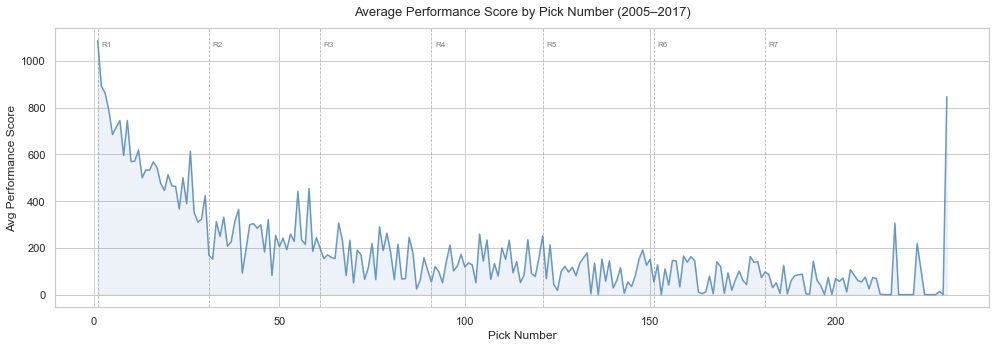

In [125]:
# Average performance score by pick number across all drafts
pick_curve = (
    df.groupby('pick_number')['performance_score']
    .mean()
    .reset_index(name='avg_performance')
)

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(pick_curve['pick_number'], pick_curve['avg_performance'],
        color='steelblue', linewidth=1.5, alpha=0.8)
ax.fill_between(pick_curve['pick_number'], pick_curve['avg_performance'],
                alpha=0.1, color='steelblue')

# Round boundary lines
round_starts = df.groupby('round')['pick_number'].min()
for r, pick in round_starts.items():
    ax.axvline(x=pick, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
    ax.text(pick + 1, ax.get_ylim()[1] * 0.95, f'R{r}',
            fontsize=8, color='gray', va='top')

ax.set_title('Average Performance Score by Pick Number (2005–2017)',
             fontsize=13, pad=12)
ax.set_xlabel('Pick Number')
ax.set_ylabel('Avg Performance Score')
plt.tight_layout()
plt.show()

The curve tells a clear story through the first four rounds: a steep, smooth decline as pick value drops with each selection. From round 5 onward the curve flattens — picks within the same round start to look increasingly similar.

Two spikes stand out at the tail end of the curve. Those aren't noise — they're worth understanding.

In [126]:
# Investigate the late-round spikes
sparse_picks = (
    df[df['pick_number'] > 210]
    .groupby('pick_number')['performance_score']
    .agg(['mean', 'count'])
    .round(1)
    .reset_index()
)
sparse_picks.columns = ['pick_number', 'avg_performance', 'n_players']
print(sparse_picks.to_string(index=False))

print("\n--- Pick 216 ---")
print(df[df['pick_number'] == 216][['draft_year', 'player_name', 'drafted_by', 'games_played', 'points', 'performance_score']].to_string(index=False))

print("\n--- Pick 230 ---")
print(df[df['pick_number'] == 230][['draft_year', 'player_name', 'drafted_by', 'games_played', 'points', 'performance_score']].to_string(index=False))

 pick_number  avg_performance  n_players
         211             68.7          9
         212              2.1          3
         213              0.0          3
         214              0.0          2
         215              0.0          2
         216            305.3          2
         217              0.0          2
         218              0.0          1
         219              0.0          1
         220              0.0          1
         221              0.0          1
         222            219.2          1
         224              0.0          1
         225              0.0          1
         226              0.0          1
         227              0.0          1
         228             13.6          1
         229              0.0          1
         230            847.3          1

--- Pick 216 ---
 draft_year    player_name          drafted_by  games_played  points  performance_score
       2005 Anton Stralman Toronto Maple Leafs         938.0   293.0      

The two spikes are explained by single outlier players at thinly populated pick numbers:

- **Pick 216**: Anton Stralman (938 GP, 610 performance score) is one of only two players ever drafted there in our dataset. His career single-handedly pulls the pick average to 305.
- **Pick 230**: Patric Hornqvist (901 GP, 847 performance score) is the *only* player drafted at pick 230 across all 13 drafts. His average *is* his score.

This happens because the NHL draft doesn't produce the same number of picks every year. Teams can acquire additional picks through trades, and compensatory picks are awarded for losing certain free agents — meaning some pick numbers only appear in one or two draft years, leaving almost no data behind.

These spikes aren't errors. They're a direct illustration of the problem with applying pick-level averages too deep into the draft: one good player with no peers at their pick number produces a baseline that's effectively meaningless. No team should be evaluated against the standard of "you needed to find the next Patric Hornqvist with your last pick."

This tells us we need a principled rule for when to use pick-level averages and when to fall back to round-level pooling.

## Finding the Boundary — Pick-Level vs Round-Level

To find where pick-level granularity stops being meaningful, we measure two things for each round:

- **Between-pick std**: how different the average performance scores are from pick to pick *within* a round. A high number means the specific pick carries real information — pick 5 looks meaningfully different from pick 25. A low number means picks within the round are largely interchangeable.
- **Within-pick std**: the average spread of individual player outcomes at any given pick number. This tells us how unpredictable results are even when we know the exact pick.

Where between-pick variation is high relative to within-pick variation, pick-level granularity is earning its keep. Where it collapses, round-level pooling is the more honest choice.

In [127]:
# Between-pick std: how different are pick-level averages from each other within a round?
pick_means = (
    df.groupby(['round', 'pick_number'])['performance_score']
    .mean()
    .reset_index(name='pick_mean')
)

between_pick_std = (
    pick_means.groupby('round')['pick_mean']
    .std()
    .reset_index(name='between_pick_std')
)

# Within-pick std: how variable are individual players at the same pick number?
within_pick_std = (
    df.groupby(['round', 'pick_number'])['performance_score']
    .std()
    .reset_index(name='within_pick_std')
    .groupby('round')['within_pick_std']
    .mean()
    .reset_index()
)

variance_summary = between_pick_std.merge(within_pick_std, on='round').round(1)
variance_summary.columns = ['Round', 'Between-Pick Std', 'Within-Pick Std']
print(variance_summary.to_string(index=False))

 Round  Between-Pick Std  Within-Pick Std
     1             183.2            321.3
     2             108.8            285.6
     3              87.1            239.9
     4              73.7            214.7
     5              94.7            188.5
     6              99.5            148.8
     7             138.2            140.9


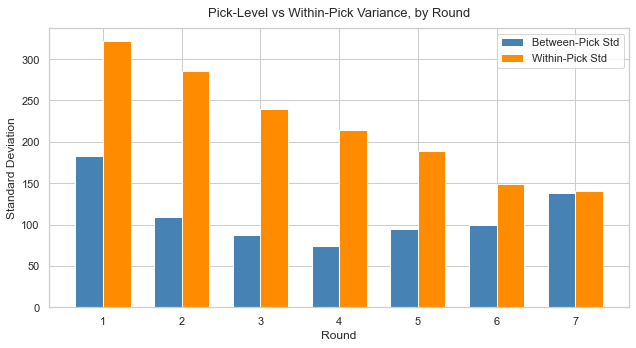

In [128]:
fig, ax = plt.subplots(figsize=(9, 5))

x = variance_summary['Round']
width = 0.35

ax.bar(x - width/2, variance_summary['Between-Pick Std'],
       width=width, label='Between-Pick Std', color='steelblue', edgecolor='white')
ax.bar(x + width/2, variance_summary['Within-Pick Std'],
       width=width, label='Within-Pick Std', color='darkorange', edgecolor='white')

ax.set_title('Pick-Level vs Within-Pick Variance, by Round', fontsize=13, pad=12)
ax.set_xlabel('Round')
ax.set_ylabel('Standard Deviation')
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.legend()
plt.tight_layout()
plt.show()

### Reading the Chart

A few things stand out:

**Rounds 1–4** show a clear, steady decline in both measures. Between-pick variation is high and meaningfully so — pick 1 looks genuinely different from pick 30. Pick-level granularity is earning its keep here.

**Rounds 5–7** tell a consistent story: between-pick std rises steadily while within-pick std continues to fall. That rising between-pick std might sound like increasing pick-level signal, but we already know what's driving it — sparse pick numbers where one or two outlier players pull the average in either direction. By round 7, within-pick std has dropped to nearly the same level as between-pick std, meaning individual picks are increasingly consistent — consistently near zero. The between-pick variation in rounds 5–7 is noise from thin data, not meaningful differentiation between positions.

### The Decision

We'll use **pick-level leave-one-out averages for rounds 1–4**, and **round-level leave-one-out averages for rounds 5–7**.

Rounds 1–4 show genuinely declining between-pick variation — the specific pick number carries real information and pick-level granularity is the right choice. From round 5 onward the pattern flips: between-pick std rises while within-pick std continues to fall. As we already saw in the curve, this is driven by sparse pick numbers with outlier players and not by meaningful pick-to-pick signal. Round-level pooling is the more honest and stable choice for rounds 5–7.

The goal is a baseline that reflects genuine historical expectation — not one that's been distorted by a Patric Hornqvist or an Anton Stralman with no peers at their pick number.

## Calculating Expected Performance

With the granularity decision made, we can now calculate expected performance for every player using leave-one-out averages.

The logic is straightforward:
- **Rounds 1–4**: for each player, take the average performance score of all *other* players drafted at the same pick number
- **Rounds 5–7**: for each player, take the average performance score of all *other* players drafted in the same round

This gives every player a baseline that reflects what was historically expected at their draft position — without them inflating their own baseline.

In [129]:
def leave_one_out_avg(group, col):
    """For each row, return the mean of all other rows in the group."""
    group_sum = group[col].sum()
    group_count = group[col].count()
    return (group_sum - group[col]) / (group_count - 1)

# Pick-level LOO for rounds 1-4
rounds_pick = df[df['round'] <= 4].copy()
rounds_pick['expected_performance'] = (
    rounds_pick.groupby('pick_number', group_keys=False)
    .apply(lambda g: leave_one_out_avg(g, 'performance_score'))
)

# Round-level LOO for rounds 5-7
rounds_round = df[df['round'] >= 5].copy()
rounds_round['expected_performance'] = (
    rounds_round.groupby('round', group_keys=False)
    .apply(lambda g: leave_one_out_avg(g, 'performance_score'))
)

# Combine
df = pd.concat([rounds_pick, rounds_round]).sort_values(
    ['draft_year', 'round', 'pick_number']
).reset_index(drop=True)

print(f"Rows with expected_performance calculated: {df['expected_performance'].notna().sum()}")
print(f"Rows missing expected_performance:         {df['expected_performance'].isna().sum()}")

Rows with expected_performance calculated: 2483
Rows missing expected_performance:         1


One player is missing an expected performance value. This is a data quirk worth understanding.

In [130]:
print(df[df['pick_number'] == 125][['draft_year', 'round', 'pick_number', 'player_name', 'drafted_by']])

      draft_year  round  pick_number          player_name           drafted_by
112         2005      4          125       Tommi Leinonen  Pittsburgh Penguins
507         2007      5          125        Brett Leffler  Washington Capitals
696         2008      5          125  Kristoffer Berglund      St. Louis Blues
886         2009      5          125             Cody Sol        Winnipeg Jets
1076        2010      5          125          Tony DeHart   New York Islanders
1267        2011      5          125         John Persson   New York Islanders
1454        2012      5          125        Doyle Somerby   New York Islanders
1641        2013      5          125      Saku Maenalanen  Nashville Predators
1829        2014      5          125   Nikolas Koberstein   Montreal Canadiens
2021        2015      5          125      Dmytro Timashov  Toronto Maple Leafs
2209        2016      5          125        Nolan Stevens      St. Louis Blues
2399        2017      5          125         Igor Sh

Pick 125 falls in round 4 in 2005 but in round 5 in every other draft year — a consequence of the draft not producing an identical number of picks per round each year. Since our round 1–4 logic groups by pick number, Tommi Leinonen ends up as the only player ever at pick 125 in round 4. Leave-one-out has no one else to average, so it returns NaN.

The fix is straightforward: fall back to the round-level leave-one-out average for any pick number with only one observation. This is the same logic we use for rounds 5–7 and the most sensible baseline available.

In [131]:
# Fallback: fill any NaN expected_performance with round-level LOO average
round_loo = (
    df.groupby('round', group_keys=False)
    .apply(lambda g: leave_one_out_avg(g, 'performance_score'))
    .reset_index(level=0, drop=True)
)

df['expected_performance'] = df['expected_performance'].fillna(round_loo)

print(f"Missing after fallback: {df['expected_performance'].isna().sum()}")
df[['player_name', 'round', 'pick_number', 'performance_score', 'expected_performance']].head(15)

Missing after fallback: 0


,player_name,round,pick_number,performance_score,expected_performance
0,Sidney Crosby,1,1,1366.28,1064.721667
1,Bobby Ryan,1,2,891.65,891.852500
2,Jack Johnson,1,3,583.05,886.094167
3,Benoit Pouliot,1,4,699.05,797.197500
4,Gilbert Brule,1,6,516.55,733.325833
5,Jack Skille,1,7,542.09,762.061667
6,Devin Setoguchi,1,8,768.36,580.902500
7,Brian Lee,1,9,291.44,783.103333
8,Luc Bourdon,1,10,40.58,613.016667
9,Anze Kopitar,1,11,1063.08,522.523000


## Calculating Draft Value

With expected performance in hand, draft value is a single subtraction.

In [132]:
df['draft_value'] = (df['performance_score'] - df['expected_performance']).round(2)

print(f"Draft value calculated for {df['draft_value'].notna().sum()} players")

print(f"\nTop 10 by draft value:")
print(df.nlargest(10, 'draft_value')[['draft_year', 'round', 'pick_number', 'player_name', 'drafted_by', 'performance_score', 'expected_performance', 'draft_value']].to_string(index=False))

print(f"\nBottom 10 by draft value:")
print(df.nsmallest(10, 'draft_value')[['draft_year', 'round', 'pick_number', 'player_name', 'drafted_by', 'performance_score', 'expected_performance', 'draft_value']].to_string(index=False))

Draft value calculated for 2484 players

Top 10 by draft value:
 draft_year  round  pick_number     player_name          drafted_by  performance_score  expected_performance  draft_value
       2015      5          135 Kirill Kaprizov      Minnesota Wild            1330.97             94.858835      1236.11
       2011      2           58 Nikita Kucherov Tampa Bay Lightning            1400.96            368.210909      1032.75
       2010      6          178      Mark Stone     Ottawa Senators            1106.96             80.206188      1026.75
       2006      3           71   Brad Marchand       Boston Bruins            1087.73            108.833636       978.90
       2011      4          104 Johnny Gaudreau      Calgary Flames            1149.87            177.635455       972.23
       2016      6          159   Brandon Hagel      Buffalo Sabres            1035.37             80.416129       954.95
       2014      1           25  David Pastrnak       Boston Bruins            127

## Sanity Check

The results pass the smell test on both ends.

The top 10 is a list of genuinely legendary steals — Kirill Kaprizov in round 5, Nikita Kucherov in round 2, Mark Stone in round 6, Brad Marchand in round 3. These are players whose careers vastly exceeded what anyone could have reasonably expected at their draft position. Draft years span 2006–2017, confirming the career length proration is working as intended — recent draftees are competing fairly with players from earlier classes.

The bottom 10 is entirely first round picks who either never stuck in the league or dramatically underperformed the expectation that comes with a high selection. Griffin Reinhart at pick 4 with a performance score of 41 is correctly identified as the worst result in the dataset. Every player in the bottom 10 was given enormous expected value by virtue of their draft position and returned almost nothing.

Zero players are missing a draft value. The leave-one-out fallback handled the one edge case cleanly.

With draft value confirmed for all 2484 players, we can now build the team aggregates for Tableau.

## Team Aggregates

In [133]:
# Overall team rankings
team_rankings = df.groupby('drafted_by').agg(
    total_draft_value=('draft_value', 'sum'),
    total_picks=('draft_value', 'count'),
    avg_draft_value_per_pick=('draft_value', 'mean')
).round(2).reset_index()

team_rankings.columns = ['team', 'total_draft_value', 'total_picks', 'avg_per_pick']
team_rankings = team_rankings.sort_values('avg_per_pick', ascending=False).reset_index(drop=True)
team_rankings['overall_rank'] = range(1, len(team_rankings) + 1)

print("NHL Team Draft Rankings 2005–2017")
print(team_rankings.to_string())

NHL Team Draft Rankings 2005–2017
                     team  total_draft_value  total_picks  avg_per_pick  overall_rank
0       Los Angeles Kings            5447.40           88         61.90             1
1         Ottawa Senators            3711.52           78         47.58             2
2    Vegas Golden Knights             330.64           10         33.06             3
3            Dallas Stars            2309.37           75         30.79             4
4         San Jose Sharks            2080.20           81         25.68             5
5     Toronto Maple Leafs            1937.60           87         22.27             6
6     Nashville Predators            1845.50           85         21.71             7
7     Tampa Bay Lightning            1841.90           86         21.42             8
8         St. Louis Blues            1389.58           89         15.61             9
9   Columbus Blue Jackets            1313.00           85         15.45            10
10      Detroit Red 

In [134]:
# Early rounds ranking — rounds 1-3 only
team_rankings_early = df[df['round'] <= 3].groupby('drafted_by').agg(
    total_draft_value=('draft_value', 'sum'),
    total_picks=('draft_value', 'count'),
    avg_draft_value_per_pick=('draft_value', 'mean')
).round(2).reset_index()

team_rankings_early = team_rankings_early.rename(columns={'drafted_by': 'team'})
team_rankings_early = team_rankings_early.sort_values('avg_draft_value_per_pick', ascending=False).reset_index(drop=True)
team_rankings_early['early_round_rank'] = range(1, len(team_rankings_early) + 1)

print("NHL Team Draft Rankings 2005–2017 — Rounds 1–3 Only")
print(team_rankings_early.to_string())

NHL Team Draft Rankings 2005–2017 — Rounds 1–3 Only
                     team  total_draft_value  total_picks  avg_draft_value_per_pick  early_round_rank
0    Vegas Golden Knights             613.24            6                    102.21                 1
1         St. Louis Blues            3309.50           42                     78.80                 2
2       Los Angeles Kings            2582.49           35                     73.79                 3
3     Pittsburgh Penguins            2049.07           28                     73.18                 4
4       Detroit Red Wings            2228.75           37                     60.24                 5
5     Washington Capitals            1548.75           29                     53.41                 6
6            Dallas Stars            1623.64           34                     47.75                 7
7     Nashville Predators            1491.27           36                     41.42                 8
8           Boston Bruins     

In [135]:
# Add hit rate (picks above expectation / total picks)
hit_rate = df.groupby('drafted_by').agg(
    hit_rate=('draft_value', lambda x: (x > 0).sum() / len(x))
).round(4).reset_index().rename(columns={'drafted_by': 'team'})

# Merge early round rank and hit rate into team_rankings
team_rankings = team_rankings.merge(
    team_rankings_early[['team', 'early_round_rank']], on='team'
).merge(hit_rate, on='team')

In [136]:
# Higher is better
for col in ['avg_per_pick', 'hit_rate']:
    team_rankings[f'{col}_pct'] = team_rankings[col].rank(pct=True).round(2)

# Lower is better (invert)
for col in ['overall_rank', 'early_round_rank']:
    team_rankings[f'{col}_pct'] = (1 - team_rankings[col].rank(pct=True)).round(2)

In [137]:
# # Team performance by draft year
# team_by_year = df.groupby(['drafted_by', 'draft_year']).agg(
#     total_draft_value=('draft_value', 'sum'),
#     total_picks=('draft_value', 'count'),
#     avg_draft_value_per_pick=('draft_value', 'mean')
# ).round(2).reset_index()

# team_by_year = team_by_year.rename(columns={'drafted_by': 'team'})
# print(f"team_by_year shape: {team_by_year.shape}")
# team_by_year.head(10)

# Team performance by draft year
team_by_year = df.groupby(['drafted_by', 'draft_year']).agg(
    total_draft_value=('draft_value', 'sum'),
    total_picks=('draft_value', 'count'),
    avg_draft_value_per_pick=('draft_value', 'mean')
).round(2).reset_index()

team_by_year = team_by_year.rename(columns={'drafted_by': 'team'})

# Add per-year rank (1 = best in league for that draft year)
team_by_year['year_rank'] = (
    team_by_year.groupby('draft_year')['avg_draft_value_per_pick']
    .rank(ascending=False, method='min')
    .astype(int)
)

print(f"team_by_year shape: {team_by_year.shape}")
team_by_year.head(10)

team_by_year shape: (391, 6)


,team,draft_year,total_draft_value,total_picks,avg_draft_value_per_pick,year_rank
0,Anaheim Ducks,2005,-394.56,5,-78.91,20
1,Anaheim Ducks,2006,-552.31,5,-110.46,25
2,Anaheim Ducks,2007,-741.27,6,-123.54,23
3,Anaheim Ducks,2008,-535.74,9,-59.53,17
4,Anaheim Ducks,2009,268.69,6,44.78,12
5,Anaheim Ducks,2010,607.03,8,75.88,6
6,Anaheim Ducks,2011,1493.73,6,248.96,4
7,Anaheim Ducks,2012,-425.01,7,-60.72,23
8,Anaheim Ducks,2013,-239.48,5,-47.90,22
9,Anaheim Ducks,2014,1153.87,5,230.77,2


In [138]:
# # Team performance by round
# team_by_round = df.groupby(['drafted_by', 'round']).agg(
#     total_draft_value=('draft_value', 'sum'),
#     total_picks=('draft_value', 'count'),
#     avg_draft_value_per_pick=('draft_value', 'mean')
# ).round(2).reset_index()

# team_by_round = team_by_round.rename(columns={'drafted_by': 'team'})
# print(f"team_by_round shape: {team_by_round.shape}")
# team_by_round.head(10)

# Team performance by round
team_by_round = df.groupby(['drafted_by', 'round']).agg(
    total_draft_value=('draft_value', 'sum'),
    total_picks=('draft_value', 'count'),
    avg_draft_value_per_pick=('draft_value', 'mean')
).round(2).reset_index()

team_by_round = team_by_round.rename(columns={'drafted_by': 'team'})

# Add per-round rank (1 = best in league for that round)
team_by_round['round_rank'] = (
    team_by_round.groupby('round')['avg_draft_value_per_pick']
    .rank(ascending=False, method='min')
    .astype(int)
)

# Add per-round percentile (higher = better, for color encoding)
team_by_round['round_rank_pct'] = (
    team_by_round.groupby('round')['avg_draft_value_per_pick']
    .rank(pct=True)
    .round(2)
)

print(f"team_by_round shape: {team_by_round.shape}")
team_by_round.head(10)

team_by_round shape: (216, 7)


,team,round,total_draft_value,total_picks,avg_draft_value_per_pick,round_rank,round_rank_pct
0,Anaheim Ducks,1,388.39,15,25.89,14,0.58
1,Anaheim Ducks,2,-183.05,16,-11.44,18,0.45
2,Anaheim Ducks,3,-856.74,12,-71.40,26,0.19
3,Anaheim Ducks,4,586.64,10,58.66,8,0.77
4,Anaheim Ducks,5,420.94,12,35.08,8,0.77
5,Anaheim Ducks,6,12.64,7,1.81,15,0.55
6,Anaheim Ducks,7,439.33,6,73.22,5,0.87
7,Arizona Coyotes,1,-961.68,18,-53.43,24,0.26
8,Arizona Coyotes,2,-935.94,13,-72.00,25,0.23
9,Arizona Coyotes,3,-743.96,14,-53.14,22,0.32


In [139]:
# Full player-level data for Player Explorer dashboard
players = df[['draft_year', 'round', 'pick_number', 'drafted_by', 'player_name',
              'position', 'games_played', 'points', 'performance_score',
              'expected_performance', 'draft_value']].copy()

players = players.rename(columns={'drafted_by': 'team'})
players['expected_performance'] = players['expected_performance'].round(2)

print(f"players shape: {players.shape}")
players.head(10)

players shape: (2484, 11)


,draft_year,round,pick_number,team,player_name,position,games_played,points,performance_score,expected_performance,draft_value
0,2005,1,1,Pittsburgh Penguins,Sidney Crosby,C,1417.0,1756.0,1366.28,1064.72,301.56
1,2005,1,2,Anaheim Ducks,Bobby Ryan,R,866.0,569.0,891.65,891.85,-0.20
2,2005,1,3,Carolina Hurricanes,Jack Johnson,D,1228.0,342.0,583.05,886.09,-303.04
3,2005,1,4,Minnesota Wild,Benoit Pouliot,L,625.0,263.0,699.05,797.20,-98.15
4,2005,1,6,Columbus Blue Jackets,Gilbert Brule,C,299.0,95.0,516.55,733.33,-216.78
5,2005,1,7,Chicago Blackhawks,Jack Skille,R,368.0,84.0,542.09,762.06,-219.97
6,2005,1,8,San Jose Sharks,Devin Setoguchi,R,516.0,261.0,768.36,580.90,187.46
7,2005,1,9,Ottawa Senators,Brian Lee,D,209.0,36.0,291.44,783.10,-491.66
8,2005,1,10,Vancouver Canucks,Luc Bourdon,D,36.0,2.0,40.58,613.02,-572.44
9,2005,1,11,Los Angeles Kings,Anze Kopitar,C,1515.0,1314.0,1063.08,522.52,540.56


## Exports

All datasets are saved to `data/outputs/` for use in the Tableau dashboard.

In [140]:
team_rankings.to_csv('../data/outputs/team_rankings.csv', index=False)
team_by_year.to_csv('../data/outputs/team_by_year.csv', index=False)
team_by_round.to_csv('../data/outputs/team_by_round.csv', index=False)
team_rankings_early.to_csv('../data/outputs/team_rankings_early.csv', index=False)
players.to_csv('../data/outputs/players.csv', index=False)

print("All files exported successfully!")
print(f"  team_rankings.csv       — {len(team_rankings)} rows")
print(f"  team_by_year.csv        — {len(team_by_year)} rows")
print(f"  team_by_round.csv       — {len(team_by_round)} rows")
print(f"  team_rankings_early.csv — {len(team_rankings_early)} rows")
print(f"  players.csv             — {len(players)} rows")

All files exported successfully!
  team_rankings.csv       — 31 rows
  team_by_year.csv        — 391 rows
  team_by_round.csv       — 216 rows
  team_rankings_early.csv — 31 rows
  players.csv             — 2484 rows


## End of Analysis

Five datasets have been exported to `data/outputs/` for use in the Tableau dashboard:

- **team_rankings.csv** — overall team draft rankings by total and average draft value
- **team_by_year.csv** — team performance broken down by draft year
- **team_by_round.csv** — team performance broken down by round
- **team_rankings_early.csv** — team rankings restricted to rounds 1–3, isolating early round scouting quality from late round opportunism
- **players.csv** — full player-level data with performance score, expected performance, and draft value for every skater in the dataset